# Clasificador KNN para reconocimiento de numeros


# Importacion de librerias


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras

from knn_algoritmo import KNN


## Carga del dataset

El dataset MNIST se carga directamente desde TensorFlow. Este dataset contiene imagenes de digitos escritos a mano, con etiquetas del 0 al 9.


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
np.unique(y_train)


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

## Visualizacion de algunos datos

Antes de usar KNN, se muestran algunas imagenes del dataset para ver como son los numeros escritos a mano.


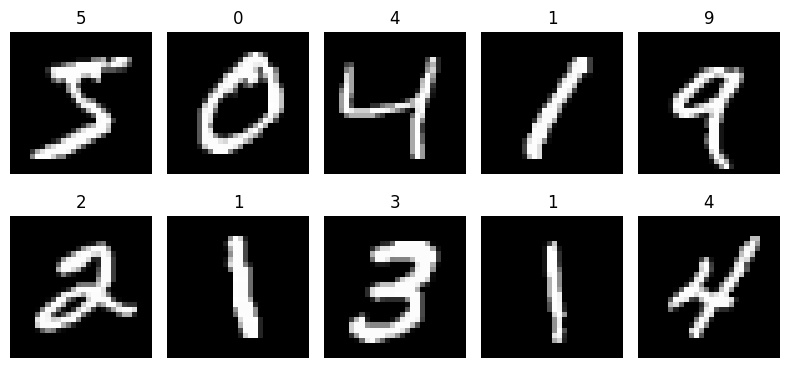

In [5]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Cantidad de datos por clase

Se revisa cuantas imagenes hay para cada numero, para verificar que el dataset esta balanceado.


In [6]:
pd.Series(y_train).value_counts().sort_index()


0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

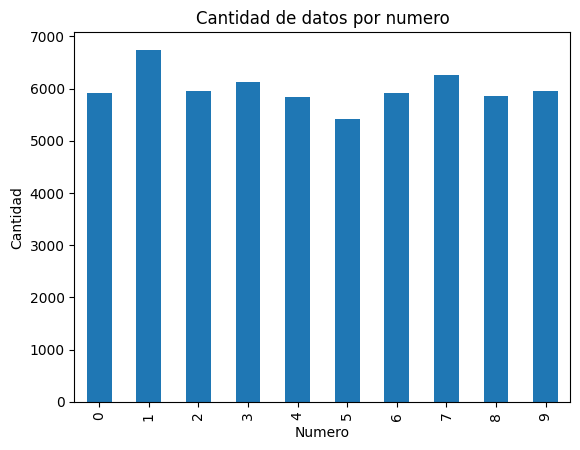

In [7]:
pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de datos por numero")
plt.xlabel("Numero")
plt.ylabel("Cantidad")
plt.show()


## Preprocesamiento de datos

Las imagenes tienen pixeles con valores entre 0 y 255. Se normalizan al rango entre 0 y 1 y luego se convierten de matrices 28x28 a vectores de 784 valores para poder calcular distancias entre imagenes.


In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)


In [9]:
print(X_train.min())
print(X_train.max())
print(X_train_flat.shape)
print(X_test_flat.shape)


0.0
1.0
(60000, 784)
(10000, 784)


## Clasificacion con KNN

KNN no entrena pesos como una red neuronal. En `entrenar`, guarda en memoria las observaciones y etiquetas de entrenamiento. Luego, cuando llega una observacion de prueba, calcula la distancia contra los datos guardados y decide usando los 3 vecinos mas cercanos.

En esta ejecucion se usa la distancia Manhattan, una metrica razonable para datos con muchas caracteristicas como las imagenes MNIST.


### Preparacion de datos para KNN

Se convierten los arreglos de NumPy a listas porque el algoritmo manual trabaja recorriendo listas. Para que la ejecucion termine en un tiempo razonable, KNN se ejecuta sobre una muestra del conjunto de entrenamiento y prueba.

Los pixeles se mantienen normalizados entre 0 y 1 para calcular la distancia Manhattan entre imagenes.


In [10]:
cantidad_entrenamiento_knn = 3000
cantidad_prueba_knn = 1000

X_train_knn = X_train_flat[:cantidad_entrenamiento_knn].tolist()
y_train_knn = y_train[:cantidad_entrenamiento_knn].tolist()

X_test_knn = X_test_flat[:cantidad_prueba_knn].tolist()
y_test_knn = y_test[:cantidad_prueba_knn].tolist()

print("Datos de entrenamiento usados en KNN:", len(X_train_knn))
print("Datos de prueba usados en KNN:", len(X_test_knn))
print("Caracteristicas por imagen:", len(X_train_knn[0]))


Datos de entrenamiento usados en KNN: 3000
Datos de prueba usados en KNN: 1000
Caracteristicas por imagen: 784


### Entrenamiento del modelo

En esta etapa el modelo solo guarda los datos de entrenamiento. No ajusta pesos como una red neuronal.


In [11]:
knn_manhattan = KNN(k=3, metrica="manhattan")
knn_manhattan.entrenar(X_train_knn, y_train_knn)


### Funciones de visualizacion

Funciones de visualizacion.


In [12]:
from visualizacion_knn import (
    crear_contexto_visualizacion,
    mostrar_comparacion_metricas,
    mostrar_comparacion_matrices_confusion,
    mostrar_individuo,
    mostrar_pca_lote,
)

contexto_visualizacion = crear_contexto_visualizacion(
    X_train_flat,
    X_test_flat,
    X_test,
    X_test_knn,
    y_test_knn,
    cantidad_entrenamiento_knn,
    y_train_knn=y_train_knn,
)


### Prediccion individual

Se toma una sola observacion de prueba para ver la imagen, la etiqueta real, la prediccion Manhattan y su ubicacion aproximada en Pca. La grafica tambien muestra celdas aproximadas de decision en 2d para ver en que region cae el individuo.


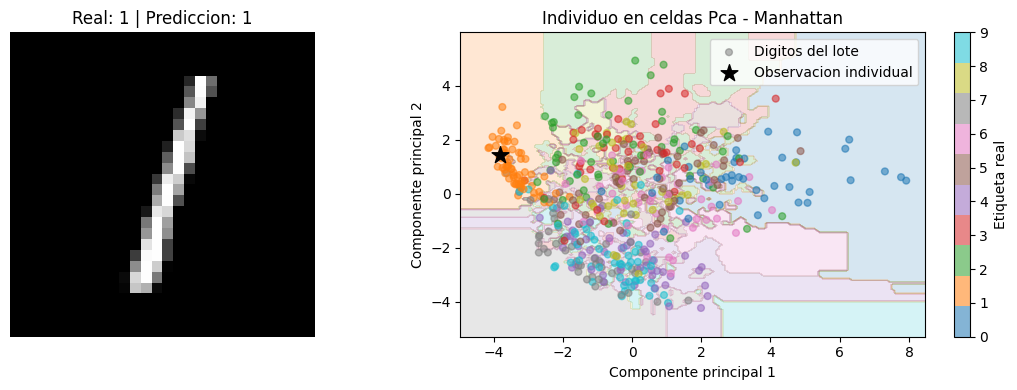

Etiqueta real: 1
Prediccion Manhattan: 1


1

In [15]:
indice_observacion = 2

mostrar_individuo(
    knn_manhattan,
    contexto_visualizacion,
    indice=indice_observacion,
    nombre_modelo="Manhattan",
)


### Prediccion en lote

Se predice el lote de prueba usando KNN con distancia Manhattan.


In [ ]:
predicciones = {
    "Manhattan": knn_manhattan.predecir_en_lote(X_test_knn)
}

resultados = pd.DataFrame({
    "real": y_test_knn,
    "pred_manhattan": predicciones["Manhattan"]
})

resultados.head(10)


### Metricas de evaluacion

Las metricas muestran el rendimiento del modelo KNN usando distancia Manhattan.


In [ ]:
mostrar_comparacion_metricas(y_test_knn, predicciones)
mostrar_comparacion_matrices_confusion(y_test_knn, predicciones)


### Visualizacion 2D de la prediccion en lote con Pca

Pca reduce las 784 caracteristicas de cada imagen a 2 componentes principales. La grafica muestra las predicciones del lote y las celdas aproximadas de decision en ese plano 2D.


In [ ]:
mostrar_pca_lote(
    contexto_visualizacion,
    y_test_knn,
    predicciones,
    nombre_modelo="Manhattan",
    k=3,
)
